# **1. 선형 회귀 분석**
선형 회귀 분석(Linear Regression)은 주어진 데이터에서 입력 변수(독립 변수)와 출력 변수(종속 변수) 사이의 관계를 직선(또는 다차원에서는 평면)으로 설명하고, 
<br>새로운 입력 값에 대한 출력을 예측하는 통계 및 머신러닝 기법입니다. 
<br>예를 들어, 공부 시간(입력 변수)과 시험 점수(출력 변수) 사이의 관계를 분석해 "공부 시간이 늘어날수록 시험 점수가 증가한다"는 패턴을 찾아냅니다. 
<br>이 과정에서 선형 회귀는 "Y = W X + b"라는 수식(기울기 W와 절편 b)으로 데이터를 표현하며, 
<br>최적의 기울기와 절편을 찾기 위해 비용 함수(Cost Function)를 최소화하는 경사 하강법(Gradient Descent) 등의 알고리즘을 사용합니다. 
<br>최종적으로 선형 회귀 모델은 주어진 입력 값에 대해 가장 적합한 예측 결과를 제공합니다.

# **2. 단항 선형 회귀**
단항 선형 회귀(Simple Linear Regression)는 하나의 독립 변수(입력 변수, X)를 사용하여 하나의 종속 변수(출력 변수, Y)를 예측하는 통계 및 머신러닝 기법입니다. 
<br>입력 변수와 출력 변수 사이의 관계를 직선(Linear Line)으로 나타내며, 데이터의 패턴을 기반으로 가장 잘 맞는 직선을 찾아내어 새로운 입력 값에 대한 출력을 예측합니다.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [6]:
torch.manual_seed(2026)

In [4]:
x_train = torch.FloatTensor([[1], [2], [3]])
y_train = torch.FloatTensor([[2], [4], [6]])
print(x_train, x_train.shape)
print(y_train, y_train.shape)

tensor([[1.],
        [2.],
        [3.]]) torch.Size([3, 1])
tensor([[2.],
        [4.],
        [6.]]) torch.Size([3, 1])


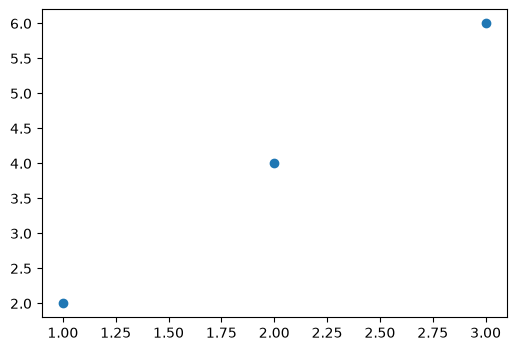

In [7]:
plt.figure(figsize=(6, 4))
plt.scatter(x_train, y_train)

In [ ]:
# y = Wx + b # -1 ~ 1 범위 내에서 무작위로 선택
model = nn.Linear(1, 1) # 입력 특성의 수, 출력 특성의 수
print(model)

y_pred = model(x_train)
print(y_pred)
print(list(model.parameters()))

# 출력은 랜덤하게 바뀜
# Linear(in_features=1, out_features=1, bias=True)
# tensor([[-1.1912],
#         [-1.8862],
#         [-2.5813]], grad_fn=<AddmmBackward0>)
# [Parameter containing:
# tensor([[-0.6950]], requires_grad=True), Parameter containing:  W 값
# tensor([-0.4962], requires_grad=True)]                          b 값

Linear(in_features=1, out_features=1, bias=True)
tensor([[-1.1912],
        [-1.8862],
        [-2.5813]], grad_fn=<AddmmBackward0>)
[Parameter containing:
tensor([[-0.6950]], requires_grad=True), Parameter containing:
tensor([-0.4962], requires_grad=True)]


In [13]:
# y = Wx + b # -1 ~ 1 범위 내에서 무작위로 선택
model = nn.Linear(1, 1) # 입력 특성의 수, 출력 특성의 수
print(model)

y_pred = model(x_train)
print(y_pred)
print(list(model.parameters()))



print()
print()
# y = Wx + b # -1 ~ 1 범위 내에서 무작위로 선택
model = nn.Linear(1, 1) # 입력 특성의 수, 출력 특성의 수
print(model)

y_pred = model(x_train)
print(y_pred)
print(list(model.parameters()))


Linear(in_features=1, out_features=1, bias=True)
tensor([[-0.5106],
        [-0.1142],
        [ 0.2822]], grad_fn=<AddmmBackward0>)
[Parameter containing:
tensor([[0.3964]], requires_grad=True), Parameter containing:
tensor([-0.9071], requires_grad=True)]


Linear(in_features=1, out_features=1, bias=True)
tensor([[0.0167],
        [0.6426],
        [1.2684]], grad_fn=<AddmmBackward0>)
[Parameter containing:
tensor([[0.6259]], requires_grad=True), Parameter containing:
tensor([-0.6091], requires_grad=True)]


In [15]:
# W: -0.6950
# b: -0.4962
# y = Wx + b
print(-0.6950 * 1 + (-0.4962))
print(-0.6950 * 2 + (-0.4962))
print(-0.6950 * 3 + (-0.4962))
print()
print()
print(0.3964 * 1 + (-0.9071))
print(0.3964 * 2 + (-0.9071))
print(0.3964 * 3 + (-0.9071))
print()
print()
print(0.6259 * 1 + (-0.6091))
print(0.6259 * 2 + (-0.6091))
print(0.6259 * 3 + (-0.6091))

-1.1911999999999998
-1.8861999999999999
-2.5812


-0.5107
-0.11430000000000007
0.2821


0.016800000000000037
0.6427
1.2686


### 손실 함수

손실 함수(Loss Function)는 머신러닝과 딥러닝 모델이 예측한 값과 실제 값 사이의 차이를 수치적으로 나타내는 함수입니다. 
<br>모델이 학습을 통해 최적의 결과를 도출하려면 이 차이를 최소화해야 합니다. 
<br>손실 함수는 예측값과 실제값의 오차를 계산하여 하나의 숫자(스칼라 값)로 반환하며, 이 값은 비용(Cost) 또는 오차(Error)라고도 불립니다. 
<br>예를 들어, 회귀 문제에서는 주로 평균 제곱 오차(MSE, Mean Squared Error)를 사용하여 예측값과 실제값 간의 평균적인 차이를 측정하고, 
<br>분류 문제에서는 교차 엔트로피 손실(Cross-Entropy Loss)을 사용해 예측 확률 분포와 실제 레이블 분포 간의 차이를 계산합니다. 
<br>손실 함수가 반환한 값은 역전파(Backpropagation)를 통해 모델의 가중치와 편향을 조정하는 데 사용됩니다. 
<br>즉, 손실 함수는 모델이 학습 과정에서 목표로 삼아야 할 방향을 알려주는 나침반 역할을 합니다.

![손실함수](./images/손실함수.png)

![파이토치_기본_손실함수](./images/파이토치_기본_손실함수.png)

In [16]:
((y_pred - y_train)**2).mean()

tensor(12.5312, grad_fn=<MeanBackward0>)

In [ ]:
# mseloss = nn.MSELoss()
# loss = mseloss(y_pred, y_train)
loss = nn.MSELoss()(y_pred, y_train)
loss

tensor(12.5312, grad_fn=<MseLossBackward0>)

### 최적화

최적화(Optimization)는 주어진 목표를 달성하기 위해 최상의 해결책(Optimal Solution)을 찾아가는 과정입니다. 
<br>머신러닝과 딥러닝에서는 주로 모델이 예측한 값과 실제 값 사이의 오차(손실 함수 값)를 최소화하는 것을 목표로 합니다. 
<br>이 과정에서 모델의 학습 가능한 파라미터(가중치와 편향)를 조정하여 손실 함수의 값을 점점 더 작게 만들어갑니다. 
<br>최적화는 주로 경사 하강법(Gradient Descent)과 같은 알고리즘을 사용해 수행되며, 손실 함수의 기울기(Gradient)를 따라가며 최저점(또는 최적점)을 찾습니다. 
<br>이 과정은 마치 산에서 가장 낮은 지점을 찾아 내려가는 것과 비슷합니다. 
<br>최적화는 단순히 손실을 줄이는 것뿐만 아니라, 학습 속도, 안정성, 과적합 방지와 같은 다양한 요소를 고려해야 하는 복합적인 과정입니다. 
<br>즉, 최적화는 모델이 데이터로부터 가장 정확하고 효율적인 예측을 할 수 있도록 파라미터를 조정하는 핵심 과정입니다.

### 경사하강법

경사하강법(Gradient Descent)은 머신러닝과 딥러닝 모델이 최적의 가중치(Weights)와 편향(Biases)를 찾기 위해 손실 함수(Loss Function)를 최소화하는 방법입니다. 
<br>이 알고리즘은 마치 산 꼭대기에서 출발해 가장 낮은 지점(최솟값)을 찾아 내려가는 과정과 비슷합니다. 
<br>먼저, 모델은 손실 함수의 기울기(Gradient)를 계산합니다. 이 기울기는 현재 지점에서 손실이 가장 빠르게 감소하는 방향을 나타냅니다. 
<br>이후, 모델은 기울기의 반대 방향으로 가중치와 편향 값을 조금씩 업데이트합니다. 이때 학습률(Learning Rate)은 한 번에 이동하는 "걸음의 크기"를 결정합니다. 
<br>학습률이 너무 크면 최적의 지점을 지나칠 수 있고, 너무 작으면 학습 속도가 매우 느려질 수 있습니다. 
<br>이 과정을 반복하면서 손실 함수 값이 점점 작아지고, 결국 최적의 가중치와 편향을 찾아내게 됩니다. 
<br>즉, 경사하강법은 모델이 더 나은 예측을 할 수 있도록 가중치를 조정해주는 핵심 최적화 알고리즘입니다.

### 학습률

학습률(Learning Rate)은 머신러닝과 딥러닝 모델이 학습할 때 가중치(Weights)와 편향(Biases)를 얼마나 크게 조정할지를 결정하는 하이퍼파라미터입니다. 
<br>경사하강법(Gradient Descent)과 같은 최적화 알고리즘에서 손실 함수(Loss Function)의 기울기(Gradient)를 따라 최적의 가중치를 찾아갈 때, 
<br>학습률은 한 번의 업데이트에서 이동하는 "걸음의 크기"를 의미합니다. 학습률이 너무 크면 최적의 가중치를 지나쳐 버리거나 학습이 불안정해질 수 있고, 
<br>너무 작으면 학습 속도가 매우 느려져 최적값에 도달하기 어려울 수 있습니다. 
<br>따라서 적절한 학습률을 선택하는 것은 모델의 학습 속도와 최적화 성능을 결정하는 중요한 요소입니다. 
<br>일반적으로 고정된 학습률을 사용하기도 하지만, 상황에 따라 학습률을 점진적으로 줄이거나 
<br>동적으로 조정하는 방법(예: Adam, Step Decay, Cyclical Learning Rate 등)이 사용되기도 합니다.

![경사하강법](./images/경사하강법.png)